In [2]:
# CVS to CSVDataset MegaSena
from pandas import read_csv
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "MegaSena_Dezena_SRT.csv"
index = "Sequence"

df = read_csv(path, index_col=index)
df.sort_values(by=[index],ascending=True,inplace=True)

In [3]:
# Creating the array to convert

array_sum = []
array_idx = []

for array_loop in range(0, 360):
    array_sum = np.append(array_sum, 0)
    array_idx = np.append(array_idx, array_loop)

for cards in df.iterrows():
    card_sum = [cards[1][1] + cards[1][2] + cards[1][3] + cards[1][4] + cards[1][5] + cards[1][6]]
    array_sum[card_sum] += 1

array_out = np.stack((array_idx, array_sum), axis=1)

for array_loop in range(0, 360):
    print(f'Card sum: {array_out[array_loop][0]:3.0f} total occurs: {array_out[array_loop][1]:7.0f}')

Card sum:   0 total occurs:       0
Card sum:   1 total occurs:       0
Card sum:   2 total occurs:       0
Card sum:   3 total occurs:       0
Card sum:   4 total occurs:       0
Card sum:   5 total occurs:       0
Card sum:   6 total occurs:       0
Card sum:   7 total occurs:       0
Card sum:   8 total occurs:       0
Card sum:   9 total occurs:       0
Card sum:  10 total occurs:       0
Card sum:  11 total occurs:       0
Card sum:  12 total occurs:       0
Card sum:  13 total occurs:       0
Card sum:  14 total occurs:       0
Card sum:  15 total occurs:       0
Card sum:  16 total occurs:       0
Card sum:  17 total occurs:       0
Card sum:  18 total occurs:       0
Card sum:  19 total occurs:       0
Card sum:  20 total occurs:       0
Card sum:  21 total occurs:       0
Card sum:  22 total occurs:       0
Card sum:  23 total occurs:       0
Card sum:  24 total occurs:       0
Card sum:  25 total occurs:       0
Card sum:  26 total occurs:       0
Card sum:  27 total occurs: 

In [4]:
df_occ = pd.DataFrame(array_out)
df_occ.sort_values(by=[1,0],ascending=True,inplace=True)

filecsv = "MegaSena_Card_Occ.csv"
df_occ.to_csv(filecsv, index=False,header=False)

In [5]:
df_sum = pd.DataFrame(array_out)
df_sum.sort_values(by=[0,1],ascending=True,inplace=True)

filecsv = "MegaSena_Card_Sum.csv"
df_sum.to_csv(filecsv, index=False,header=False)

df_sum.head()

,0,1
0,0.0,0.0
1,1.0,0.0
2,2.0,0.0
3,3.0,0.0
4,4.0,0.0


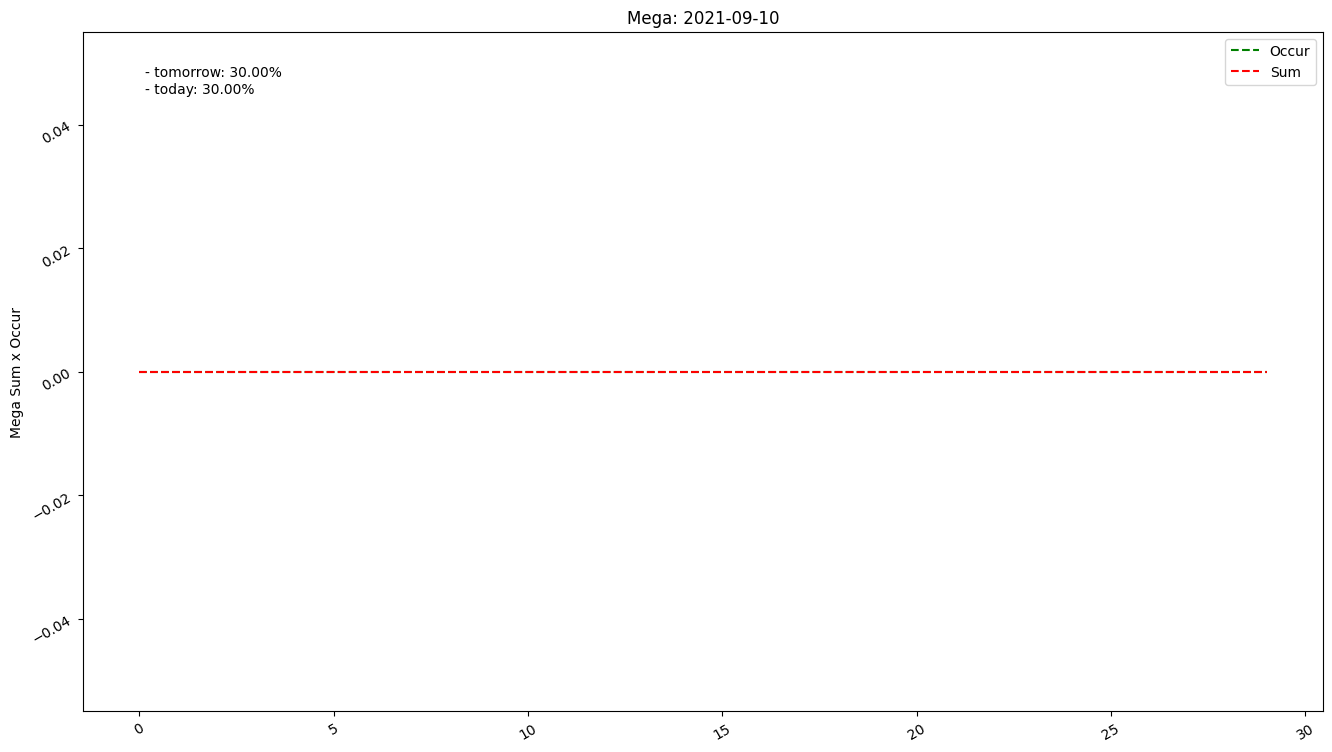

In [13]:
today = date.today()
no=30
name = 'Mega'

fig = plt.figure(figsize=(16,9), dpi=100)
ax = fig.add_subplot(111)

ax.plot(df_occ[0][:no],df_occ[1][:no],'g--',label = 'Occur')
ax.plot(df_sum[0][:no],df_sum[1][:no],'r--',label = 'Sum')
ax.legend()
ax.set_ylabel(f'{name} Sum x Occur')
ax.set_title(f'{name}: {today}')
plt.xticks(rotation=30)
plt.yticks(rotation=30)

#pct = y1_pred.data.squeeze().tolist()[:5]
#df_single = pd.DataFrame(pct,columns=[f'{name}'])
#df_single.round(2)
df_pred = pd.concat([df_occ,df_sum],axis=0)
ax.text(0.05, 0.95,  f'- tomorrow: {no:2.2f}%\n- today: {no:2.2f}%\n', ha='left', va='top', transform=ax.transAxes)
fig.savefig(f'./{today}_{name}')

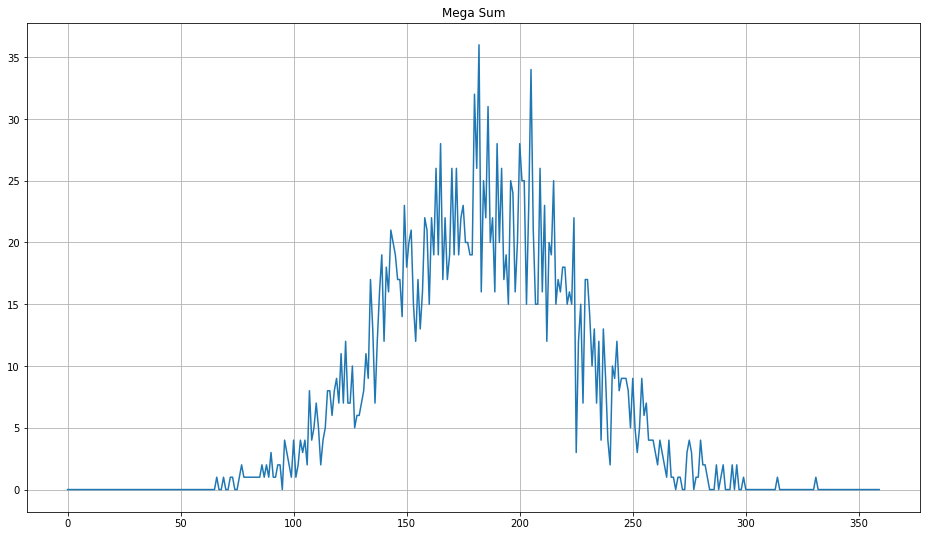

In [11]:
#Obtem os dados via servico Yahoo
df_sum = pd.DataFrame(array_out)
df_sum.sort_values(by=[0,1],ascending=True,inplace=True)
graph_title = "Mega Sum"
#Desenha o grafico com base nos parametros 
graph = df_sum[1].plot(figsize=(16, 9), grid=True, title=graph_title)
image_name = "MegaSena_Card_Sum.png"
#Salva o grafico para consulta
graph.figure.savefig(image_name)

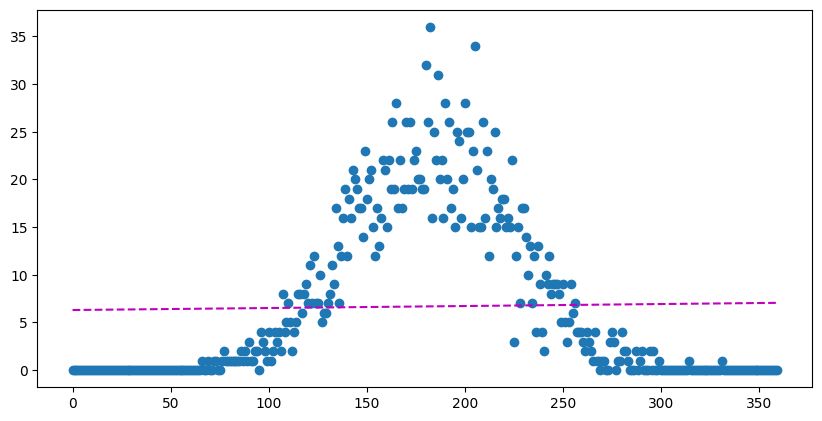

In [18]:
plt.figure(figsize=(12,6), dpi=100)
plt.subplot(111)
plt.scatter(df_sum[0],df_sum[1])

pfit = np.polyfit(df_sum[0], df_sum[1], 1)
trend_line_model = np.poly1d(pfit)

plt.plot(df_sum[0], trend_line_model(df_sum[0]), "m--") 
plt.show()